# Experiment No. 09

# Support Vector Machines and Kernel Effects

## AIM

To implement a **Support Vector Machine (SVM)** classifier and study the effect of the **regularisation parameter C** and **RBF kernel parameter γ** on the decision boundary, margin, support vectors, underfitting, and overfitting.

# OBJECTIVES

1. To understand the concept of a **maximum-margin classifier**.
2. To implement a **linear-kernel SVM** using SVC.
3. To visualize the SVM decision boundary using two features.
4. To study the effect of different values of **C**.
5. To understand the concept of **soft margin** and misclassification tolerance.
6. To implement an SVM with an **RBF kernel**.
7. To study the effect of different values of **γ**.
8. To identify underfitting and overfitting from decision-boundary plots.
9. To compare linear and nonlinear decision boundaries.
10. To select a suitable combination of **kernel, C, and γ** based on the observed results.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [4]:
# Load dataset
data = load_breast_cancer()

X_full = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target, name="target")

print("Dataset Shape:", X_full.shape)

display(X_full.head())

Dataset Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Dataset information
print("Target Classes:")
print(data.target_names)

print("\nClass Distribution:")
print(y.value_counts())

print("\nMissing Values:")
print(X_full.isnull().sum().sum())

Target Classes:
['malignant' 'benign']

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing Values:
0


In [6]:
# Select two features
feature_names = ["mean radius", "mean texture"]

X = X_full[feature_names]

print("Selected Features:")
display(X.head())

Selected Features:


,mean radius,mean texture
0,17.99,10.38
1,20.57,17.77
2,19.69,21.25
3,11.42,20.38
4,20.29,14.34


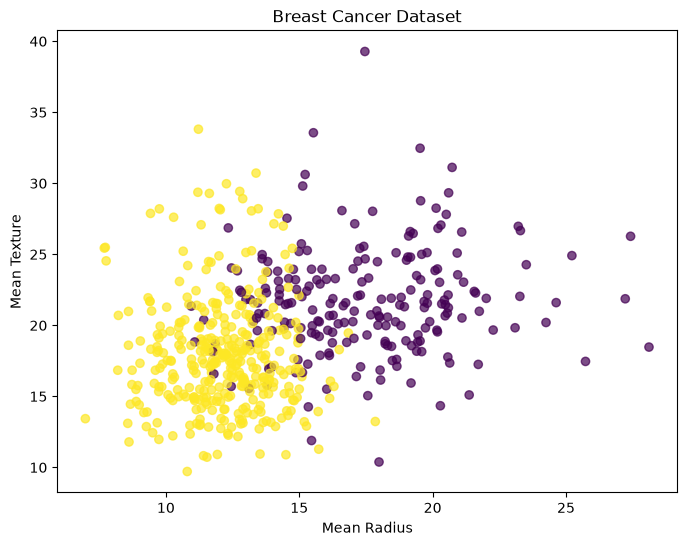

In [7]:
# Visualize the original data

plt.figure(figsize=(8, 6))

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Breast Cancer Dataset")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 398
Testing samples: 171


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")

Training data scaled successfully.


In [10]:
linear_svm = SVC(
    kernel="linear",
    C=1
)

linear_svm.fit(X_train_scaled, y_train)

train_pred = linear_svm.predict(X_train_scaled)
test_pred = linear_svm.predict(X_test_scaled)

print("Linear SVM")
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))
print("Number of Support Vectors:", len(linear_svm.support_))

Linear SVM
Training Accuracy: 0.8919597989949749
Testing Accuracy: 0.8713450292397661
Number of Support Vectors: 114


In [11]:
def plot_decision_boundary(model, X_data, y_data, title):
    
    x_min = X_data[:, 0].min() - 1
    x_max = X_data[:, 0].max() + 1
    y_min = X_data[:, 1].min() - 1
    y_max = X_data[:, 1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    
    mesh = np.c_[xx.ravel(), yy.ravel()]
    
    Z = model.predict(mesh)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    
    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.2
    )
    
    plt.scatter(
        X_data[:, 0],
        X_data[:, 1],
        c=y_data,
        edgecolors="k",
        alpha=0.7
    )
    
    # Highlight support vectors
    support_vectors = model.support_vectors_
    
    plt.scatter(
        support_vectors[:, 0],
        support_vectors[:, 1],
        s=100,
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        label="Support Vectors"
    )
    
    plt.xlabel("Standardized Mean Radius")
    plt.ylabel("Standardized Mean Texture")
    plt.title(title)
    plt.legend()
    plt.show()

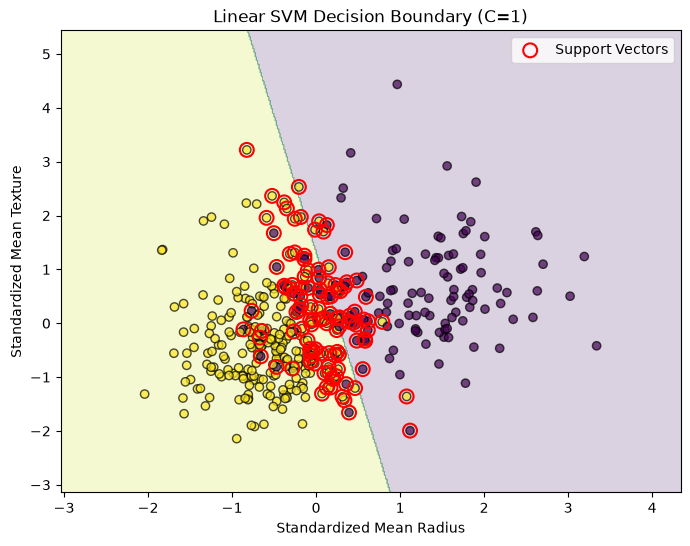

In [12]:
plot_decision_boundary(
    linear_svm,
    X_train_scaled,
    y_train,
    "Linear SVM Decision Boundary (C=1)"
)

In [13]:
C_values = [0.01, 1, 100]

linear_results = []

for C in C_values:
    
    model = SVC(
        kernel="linear",
        C=C
    )
    
    model.fit(X_train_scaled, y_train)
    
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    linear_results.append({
        "Kernel": "Linear",
        "C": C,
        "Gamma": "-",
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "No. of Support Vectors": len(model.support_)
    })

linear_results = pd.DataFrame(linear_results)

display(linear_results)

,Kernel,C,Gamma,Train Accuracy,Test Accuracy,No. of Support Vectors
0,Linear,0.01,-,0.856784,0.877193,220
1,Linear,1.00,-,0.891960,0.871345,114
2,Linear,100.00,-,0.891960,0.871345,108


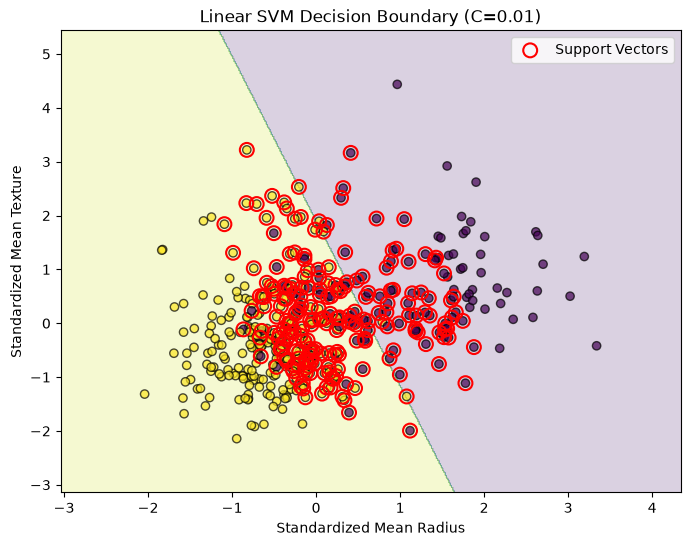

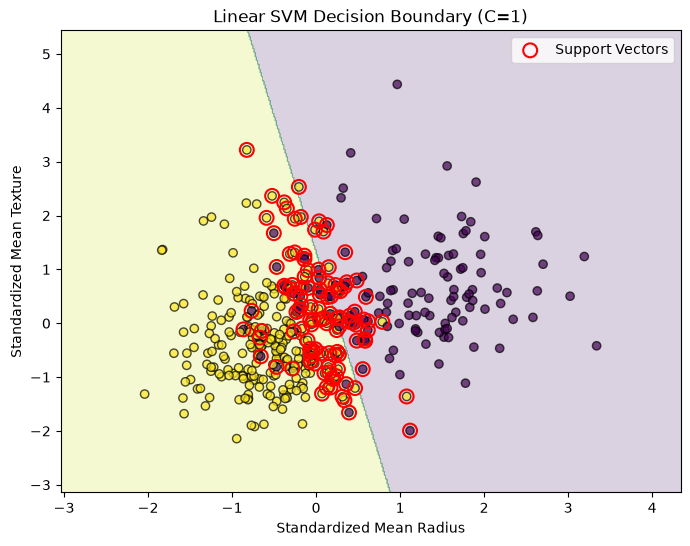

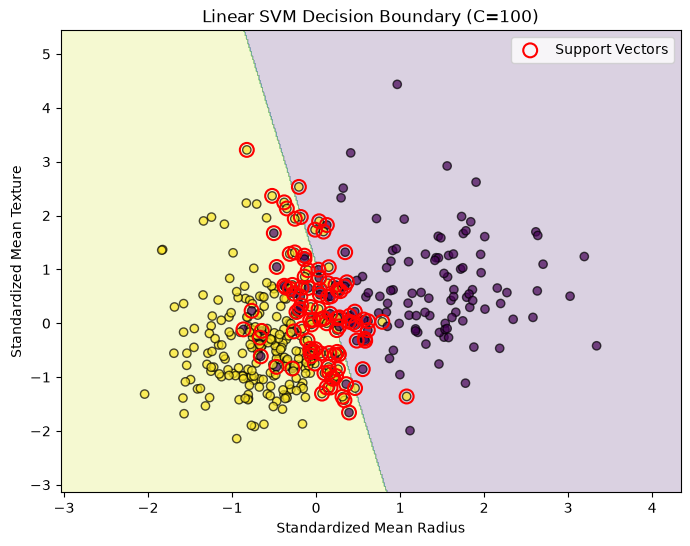

In [14]:
for C in C_values:
    
    model = SVC(
        kernel="linear",
        C=C
    )
    
    model.fit(X_train_scaled, y_train)
    
    plot_decision_boundary(
        model,
        X_train_scaled,
        y_train,
        f"Linear SVM Decision Boundary (C={C})"
    )

In [15]:
gamma_values = [0.01, 0.1, 1, 10]

rbf_results = []

for gamma in gamma_values:
    
    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma
    )
    
    model.fit(X_train_scaled, y_train)
    
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    rbf_results.append({
        "Kernel": "RBF",
        "C": 1,
        "Gamma": gamma,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "No. of Support Vectors": len(model.support_)
    })

rbf_results = pd.DataFrame(rbf_results)

display(rbf_results)

,Kernel,C,Gamma,Train Accuracy,Test Accuracy,No. of Support Vectors
0,RBF,1,0.01,0.874372,0.888889,188
1,RBF,1,0.10,0.902010,0.888889,129
2,RBF,1,1.00,0.909548,0.883041,122
3,RBF,1,10.00,0.927136,0.883041,220


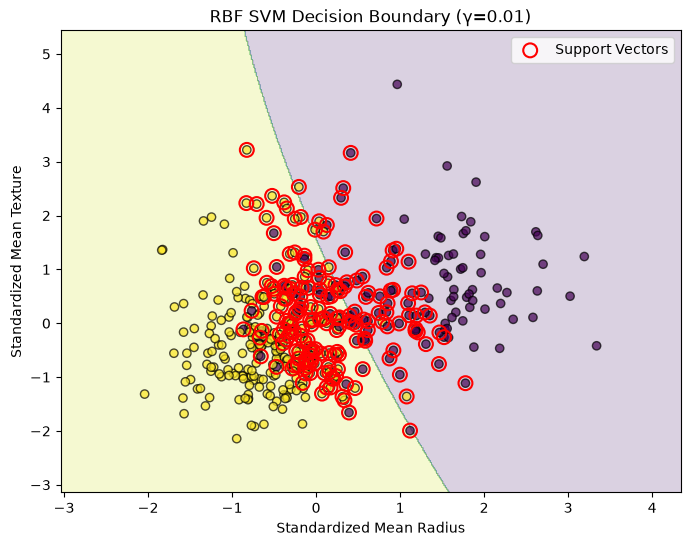

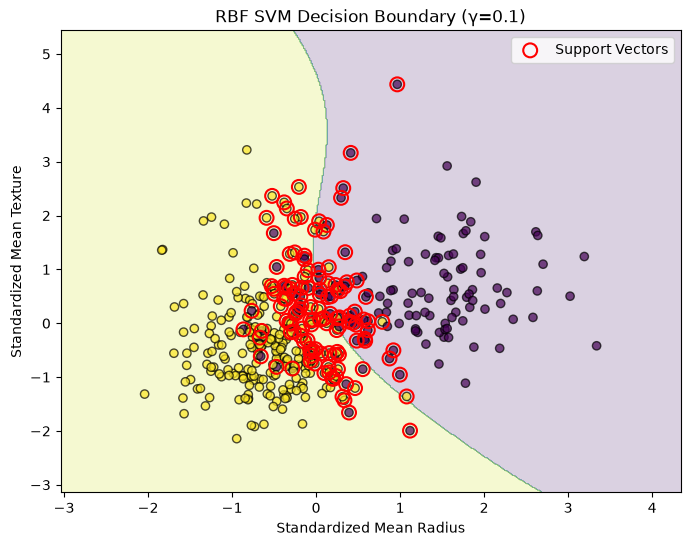

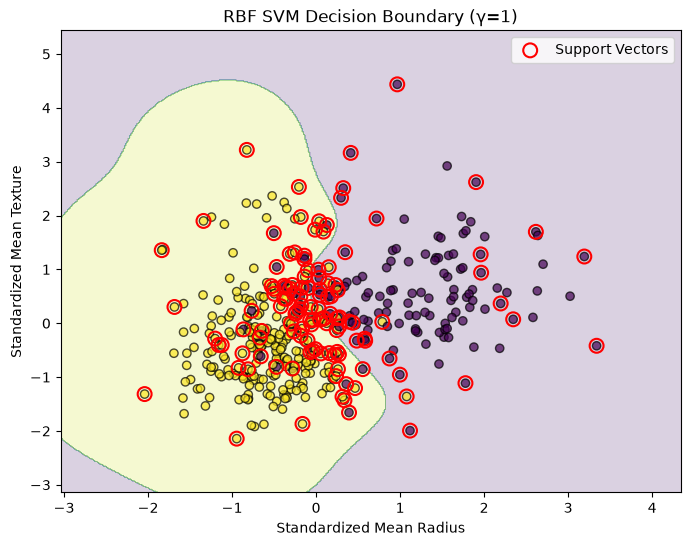

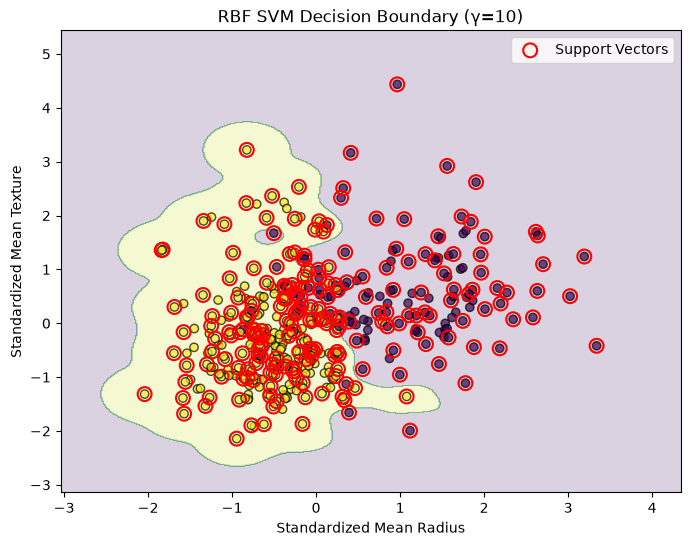

In [16]:
for gamma in gamma_values:
    
    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma
    )
    
    model.fit(X_train_scaled, y_train)
    
    plot_decision_boundary(
        model,
        X_train_scaled,
        y_train,
        f"RBF SVM Decision Boundary (γ={gamma})"
    )

In [17]:
all_results = pd.concat(
    [linear_results, rbf_results],
    ignore_index=True
)

display(all_results)

,Kernel,C,Gamma,Train Accuracy,Test Accuracy,No. of Support Vectors
0,Linear,0.01,-,0.856784,0.877193,220
1,Linear,1.00,-,0.891960,0.871345,114
2,Linear,100.00,-,0.891960,0.871345,108
3,RBF,1.00,0.01,0.874372,0.888889,188
4,RBF,1.00,0.1,0.902010,0.888889,129
5,RBF,1.00,1.0,0.909548,0.883041,122
6,RBF,1.00,10.0,0.927136,0.883041,220


In [18]:
# Sort models by test accuracy

sorted_results = all_results.sort_values(
    by="Test Accuracy",
    ascending=False
)

display(sorted_results)

,Kernel,C,Gamma,Train Accuracy,Test Accuracy,No. of Support Vectors
3,RBF,1.00,0.01,0.874372,0.888889,188
4,RBF,1.00,0.1,0.902010,0.888889,129
5,RBF,1.00,1.0,0.909548,0.883041,122
6,RBF,1.00,10.0,0.927136,0.883041,220
0,Linear,0.01,-,0.856784,0.877193,220
1,Linear,1.00,-,0.891960,0.871345,114
2,Linear,100.00,-,0.891960,0.871345,108


In [19]:
best_model = all_results.loc[
    all_results["Test Accuracy"].idxmax()
]

print("Best Configuration:")
print(best_model)

Best Configuration:
Kernel                         RBF
C                              1.0
Gamma                         0.01
Train Accuracy            0.874372
Test Accuracy             0.888889
No. of Support Vectors         188
Name: 3, dtype: object


# OBSERVATION

- A **linear SVM** produces a linear decision boundary.
- Changing `C` changes the trade-off between margin width and classification errors.
- A small `C` generally allows more margin violations and produces a wider-margin solution.
- A large `C` places greater emphasis on correctly classifying training observations.
- The **RBF kernel** produces nonlinear decision boundaries.
- A small `gamma` produces a smoother decision boundary.
- Increasing `gamma` makes the boundary increasingly flexible.
- Very large `gamma` can cause the model to fit individual training observations and may lead to overfitting.
- The number of support vectors can change with the kernel and hyperparameter values.
- SVM performance depends strongly on appropriate feature scaling and hyperparameter selection.

# CONCLUSION

Support Vector Machine classifiers were successfully implemented using both **linear and RBF kernels**.

The effect of the regularisation parameter `C` was studied using a linear kernel, while the effect of `gamma` was studied using an RBF kernel. Decision boundaries were visualized using two standardized features.

The experiment demonstrated that a linear kernel is suitable when the classes can be separated using an approximately linear boundary, whereas the RBF kernel can model nonlinear relationships.

A suitable combination of kernel, `C`, and `gamma` should be selected based on **test or cross-validation performance, generalisation, and model complexity**, rather than training accuracy alone.